## 1

In [119]:
import numpy.linalg as la
import numpy as np
import time
import matplotlib.pyplot as plt

In [120]:
def LDU(A):
    A = np.array(A)
    r,c = A.shape
    L = np.zeros((r,c))
    D = np.zeros((r, c))
    U = np.zeros((r, c))
    for i in range(r):
        for j in range(c):
            if i == j:
                D[i][j] = A[i][j]
            elif i > j:
                L[i][j] = A[i][j]
            else:  # i < j
                U[i][j] = A[i][j]
    return L,D,U

In [121]:
times = []
def jacobi(A, b):
    n = len(b)
    x = np.zeros(n)
    tol = 1e-8
    max_iter = 1000
    L,D,U = LDU(A)
    D_inv = la.inv(D)
    start = time.time()
    for k in range(max_iter):
        x_new = D_inv @ (b - (L + U) @ x)
        if np.linalg.norm(x_new - x, np.inf) < tol:
            end = time.time()
            return x_new, k + 1, end - start
        x = x_new.copy()
    end = time.time()
    print("Jacobi did not converge within", max_iter, "iterations")
    return x, max_iter, end - start

    

In [122]:
def gauss_seidel(A, b):
    L, D, U = LDU(A)
    n = len(b)
    x = np.zeros(n)
    tol = 1e-8
    max_iter = 1000

    start = time.time()

    for k in range(max_iter):
        x_new = x.copy()

        for i in range(n):
            sum1 = np.dot((L + D)[i, :i], x_new[:i])   # updated values
            sum2 = np.dot(U[i, i+1:], x[i+1:])         # old values
            x_new[i] = (b[i] - sum1 - sum2) / D[i, i]

        if np.linalg.norm(x_new - x, np.inf) < tol:
            end = time.time()
            return x_new, k + 1, end - start

        x = x_new.copy()

    end = time.time()
    print("Gauss–Seidel did not converge within", max_iter, "iterations")
    return x, max_iter, end - start



In [ ]:
def spectral_radius(matrix):
    eigvals = np.linalg.eigvals(matrix)
    return max(abs(eigvals))

### 1a.

In [156]:
A1 = np.array([[1, -0.5],[-0.5, 1]], dtype=float)

A2 = np.array([[1, -0.75],[-0.5, 1]], dtype=float)

b = np.array([1, 1], dtype=float)
x0 = np.zeros_like(b)

for A in [A1, A2]:
    L,D,U = LDU(A)
    D_inv = la.inv(D)
    B_jacobi = -D_inv @ (L + U)
    #print(D,'\n',L,'\n',U,'\n',D_inv,'\n',B_jacobi)
    rho = spectral_radius(B_jacobi)
    x_sol, its, t = Jacobi(A, b)
    print(f"{A}: rho(Jacobi) = {rho:.4f}, iterations = {its}, time = {t:.6f}s, eigenvalues = {np.linalg.eigvals(A)}")

[[ 1.  -0.5]
 [-0.5  1. ]]: rho(Jacobi) = 0.5000, iterations = 28, time = 0.000000s, eigenvalues = [1.5 0.5]
[[ 1.   -0.75]
 [-0.5   1.  ]]: rho(Jacobi) = 0.6124, iterations = 39, time = 0.000998s, eigenvalues = [1.61237244 0.38762756]


Based on the diagonal dominance, for which matrix would you expect the Jacobi method to terminate in fewer iterations? For which matrix is the Jacobi method actually faster, and why do you think that is the case?

Considering A1 is more diagonally dominant compared to A2, I expected A1 to possible to terminate faster because the spectral radius is smaller. This was proven right because the sums of each column in A1 are greater than or equal to the sums of each column in A2.

### 1b.


Running for n = 49...
  Jacobi: 28 iterations, 0.0000 s
  Gauss–Seidel: 10 iterations, 0.0094 s

Running for n = 83...
  Jacobi: 28 iterations, 0.0014 s
  Gauss–Seidel: 10 iterations, 0.0171 s

Running for n = 139...
  Jacobi: 29 iterations, 0.0027 s
  Gauss–Seidel: 10 iterations, 0.0321 s

Running for n = 232...
  Jacobi: 29 iterations, 0.0105 s
  Gauss–Seidel: 10 iterations, 0.1603 s

Running for n = 387...
  Jacobi: 29 iterations, 0.0344 s
  Gauss–Seidel: 10 iterations, 3.7035 s

Running for n = 645...
  Jacobi: 29 iterations, 0.0880 s
  Gauss–Seidel: 10 iterations, 15.9242 s

Running for n = 1077...
  Jacobi: 29 iterations, 0.2076 s
  Gauss–Seidel: 10 iterations, 72.7578 s

Running for n = 1796...
  Jacobi: 29 iterations, 0.5848 s
  Gauss–Seidel: 10 iterations, 341.6003 s

Running for n = 2997...
  Jacobi: 29 iterations, 1.8362 s
  Gauss–Seidel: 10 iterations, 1629.3608 s

Running for n = 4999...
  Jacobi: 29 iterations, 5.7426 s
  Gauss–Seidel: 10 iterations, 7956.4385 s


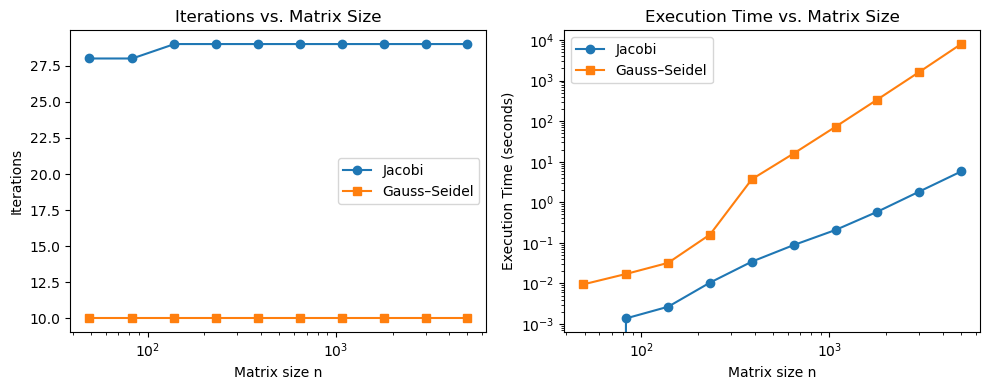

In [124]:
ns = np.logspace(np.log10(50), np.log10(5000), 10, dtype=int)

jacobi_iters, gs_iters = [], []
jacobi_times, gs_times = [], []

for n in ns:
    print(f"Running for n = {n}...")
    B = np.random.rand(n, n)
    A = B + n * np.eye(n)

    x_true = np.ones(n)
    b = A @ x_true
    _, it_j, time_j = jacobi(A, b)
    jacobi_iters.append(it_j)
    jacobi_times.append(time_j)
    print(f"Jacobi:{it_j}iterations,{time_j:.4f}s")

    _, it_g, time_g = gauss_seidel(A, b)
    gs_iters.append(it_g)
    gs_times.append(time_g)
    print(f"Gauss–Seidel:{it_g}iterations,{time_g:.4f}s")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(ns, jacobi_iters, 'o-', label='Jacobi')
plt.plot(ns, gs_iters, 's-', label='Gauss–Seidel')
plt.xscale('log')
plt.xlabel('Matrix size n')
plt.ylabel('Iterations')
plt.title('Iterations vs. Matrix Size')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ns, jacobi_times, 'o-', label='Jacobi')
plt.plot(ns, gs_times, 's-', label='Gauss–Seidel')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Matrix size n')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time vs. Matrix Size')
plt.legend()
plt.tight_layout()
plt.show()

Based on the plots generated, when it comes to the matrix size and iterations, Gauss-Siedel consistantly takes the same number of iterations till convergence (10) while for Jacobi, as the Matrix size increases, so does the number of iterations. However, when it comes to the execution time, Jacobi is much quicker compared to Gauss-Siedel. Jacobi takes a more linear amount of time, while the Gauss- Seidel takes a more exponential amount of time. This makes sense as when I look back at my approaches for the 2 functions, Jacobi utilizes linear algebra and rescuces all the matricies so it can be multiplied by a vector.  When looking at the code for the Gauss-Seidel, you wpuld need to continuously comput dot products and update the values of the matricies. Thus, it can result in an exponential run time.

## 2

In [161]:
def test_jacobi_vs_gs(num_tests=10000, seed=42):
    np.random.seed(seed)
    found = False
    for t in range(num_tests):
        A = np.random.randint(-1000, 1000, (3, 3))
        # Skip singular or diagonal-zero matrices
        if np.any(np.diag(A) == 0):
            continue
        L, D, U = LDU(A)

        # Iteration matrices
        try:
            B_J = -np.linalg.inv(D) @ (L + U)
            B_GS = -np.linalg.inv(D + L) @ U
        except np.linalg.LinAlgError:
            continue

        rho_J = spectral_radius(B_J)
        rho_GS = spectral_radius(B_GS)

        if rho_J < 1 and rho_GS >= 1:
            found = True
            print(f"Found candidate matrix (test #{t}):")
            print(A)
            print(f"ρ(Jacobi) = {rho_J:.4f}")
            print(f"ρ(Gauss–Seidel) = {rho_GS:.4f}")
            break

    if not found:
        print("No such 3x3 matrix found after", num_tests, "tests.")
        print("Likely none exists or it is extremely rare.")

In [163]:
test_jacobi_vs_gs(10000, 42)

Found candidate matrix (test #138):
[[ 531  297  529]
 [-195 -262  906]
 [  38  215  654]]
ρ(Jacobi) = 0.8355
ρ(Gauss–Seidel) = 1.0169


Yes it is possible to find a matrix where Jacobi converges and Gauss-Seidel does not.